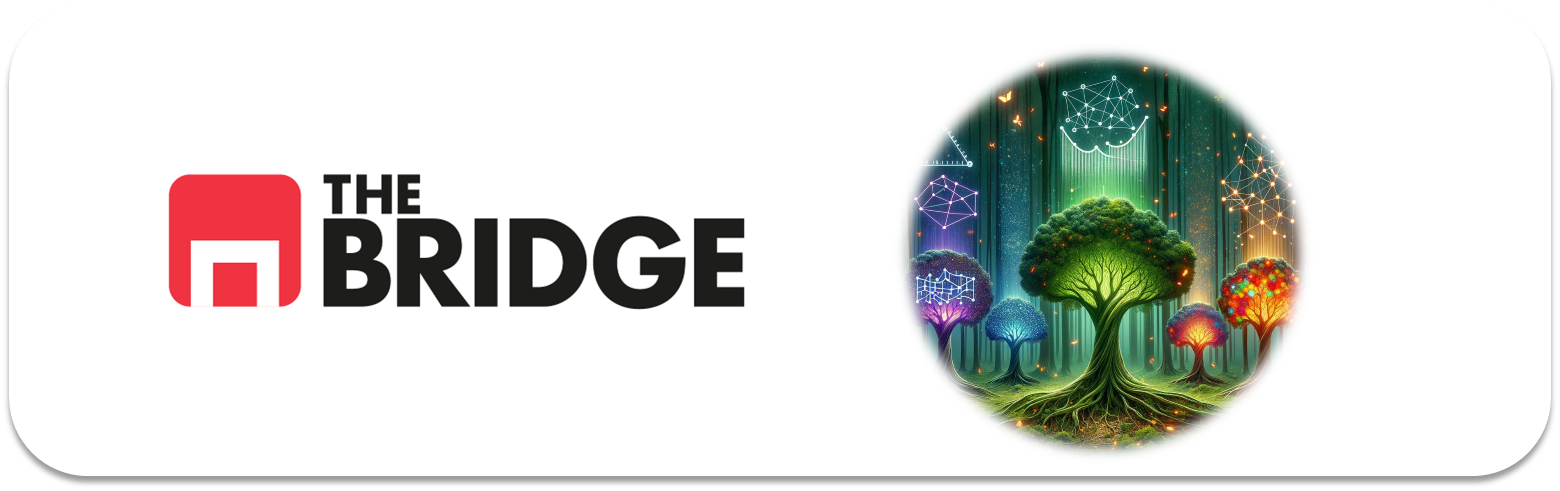

## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [13]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado y preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Modelos de ejemplo
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Métricas
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, r2_score, classification_report, ConfusionMatrixDisplay

# Otros
import warnings
warnings.filterwarnings('ignore')  # evita mensajes molestos en el notebook

pd.options.mode.copy_on_write = True

### Descripción

En el directorio data encontrarás un dataset que contiene datos relacionados con campañas de marketing directo de una institución bancaria portuguesa (es el dataset "Bank Marketing" de la UCI Machine Learning Repository). Los datos se recopilaron de campañas de marketing telefónico, donde el objetivo principal era predecir si el cliente se suscribiría a un depósito a plazo.

La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo. Sigue los pasos necesarios de un proceso de ML para crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

Tendrás que hacer la limpieza, split, minieda, selección, tratamiento, primeros entrenamientos, optimización, comparación y evaluación según tu mejor criterio. Eso sí, es obligatorio:
- Identificar el target y analizar su distribución
- Realizar una optimización de hiperparámetros, escogiendo un grid medianemante razonado
- Comparar con el modelo baseline
- Evaluar contra test

AYUDA: La dirección del banco nos proporciona estas notas (en inglés):

 
   **bank client data:**  
   1 - age (numeric)  
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
   4 - education (categorical: "unknown","secondary","primary","tertiary")  
   5 - default: has credit in default? (binary: "yes","no")  
   6 - balance: average yearly balance, in euros (numeric)   
   7 - housing: has housing loan? (binary: "yes","no")  
   8 - loan: has personal loan? (binary: "yes","no")   

   **related with the last contact of the current campaign:**  
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
  10 - day: last contact day of the month (numeric)  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  12 - duration: last contact duration, in seconds (numeric)    

   **other attributes:**  
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  

## Paso 1: Cargar datos

In [14]:
df = pd.read_csv("./data/bank-full.csv", sep=";")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [16]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## Paso 2: Definición del problema

Como necesitamos predecir si un cliente comprará o no un producto ("yes" o "no") estamos ante un problema de clasificación binaria y supervisada porque le resultado se encuentra eN el dataset en la variable "y", que será el target.

In [17]:
target = ["y"]
df[target].value_counts(normalize=True)

y  
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

Observamos que el target está muy desbalanceado

## Paso 3: Divisón de Train y Test

In [18]:
x = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y) # Estratificar por el target para reflejar en test y train el desbalanceo existente.

In [19]:
print("Train:", X_train.shape)
print(y_train.value_counts(normalize=True))

print("\nTest:", X_test.shape)
print(y_test.value_counts(normalize=True))

Train: (36168, 16)
y  
no     0.883018
yes    0.116982
Name: proportion, dtype: float64

Test: (9043, 16)
y  
no     0.883003
yes    0.116997
Name: proportion, dtype: float64


## Paso 4: Limpieza de los datos

In [20]:
# Revisar valores faltantes
print("Nulos:", X_train.isna().sum())

# Eliminación de duplicados
X_train = X_train.drop_duplicates()

# Revisar tipo de datos
print(X_train.dtypes)

Nulos: age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
dtype: int64
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
dtype: object


## Comprensión de variables, mini-EDA.

### Estudio del target

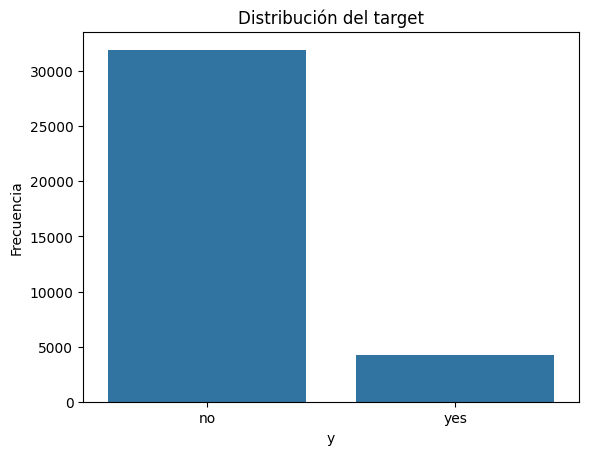

In [21]:
# Clasificación
sns.countplot(x=y_train[target[0]])
plt.title("Distribución del target")
plt.xlabel("y")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.show()

Aquí observamos visualmente el gran desbalanceo de la variable target, que ya vimos anteriormente.

### Correlación entre features numéricas

<Axes: >

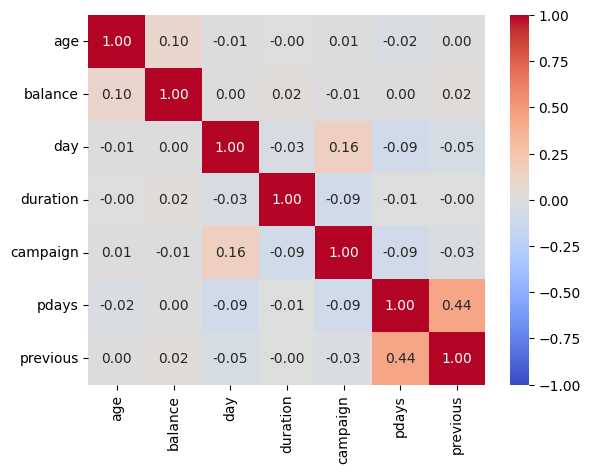

In [22]:
sns.heatmap(X_train.corr(numeric_only=True), annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="coolwarm")

No se observan correlaciones importantes entre features que justifique la eliminación de alguna

### Analisis de la relación de las variables numéricas con el target

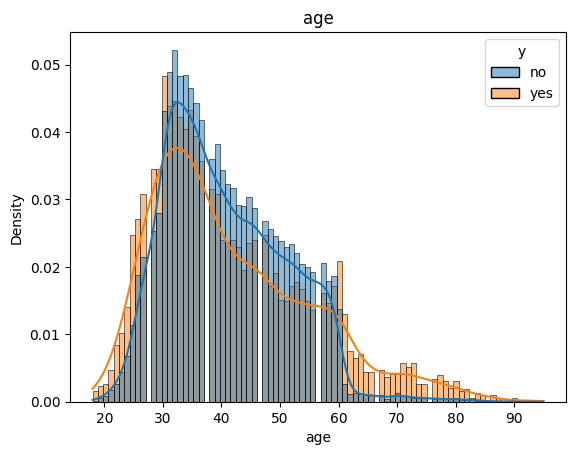

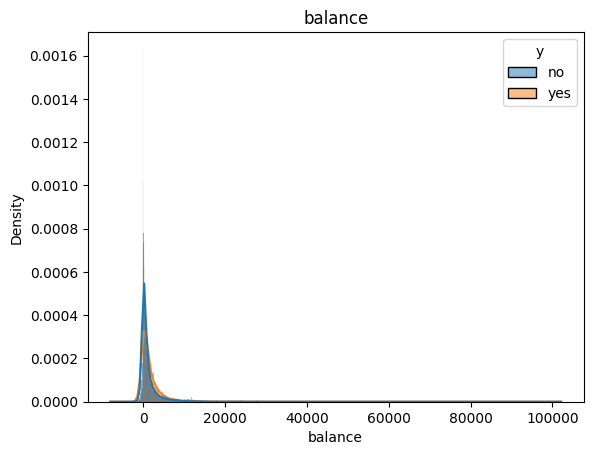

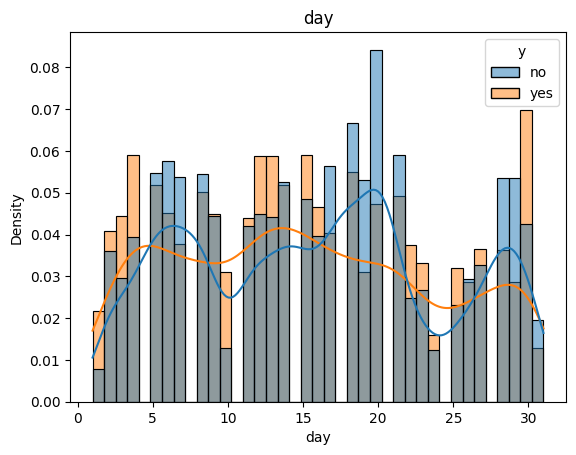

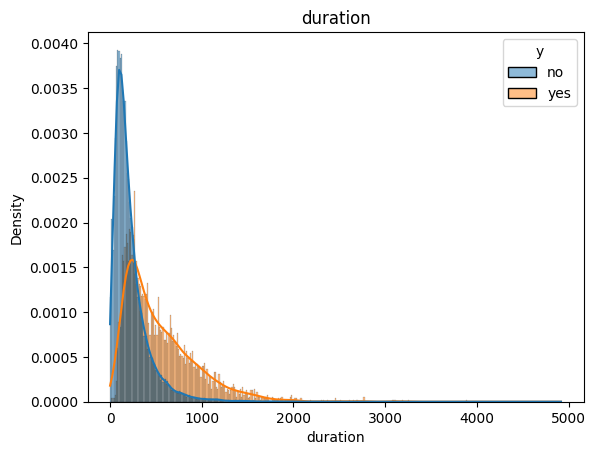

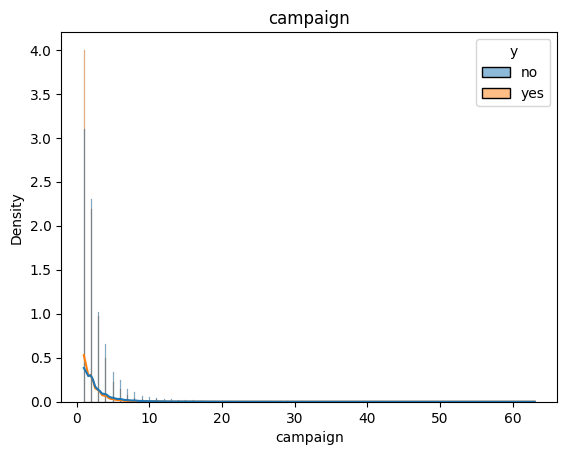

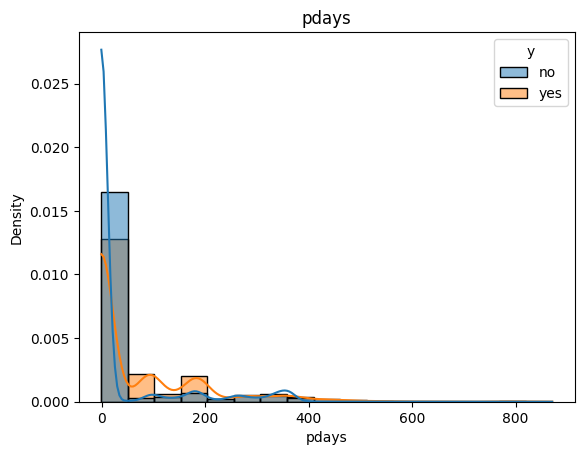

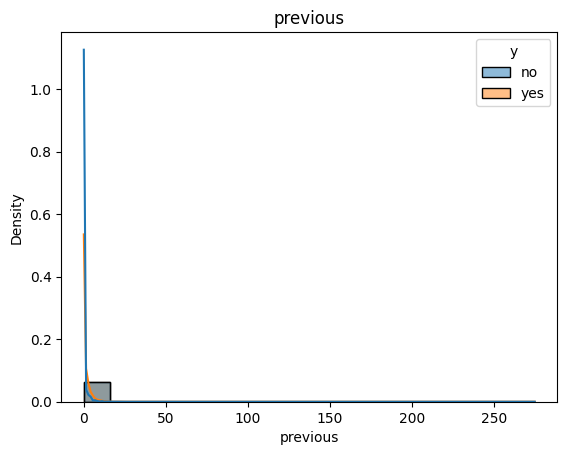

In [23]:
num_cols = X_train.select_dtypes(include="number").columns

for col in num_cols:
    sns.histplot(data=X_train, x=col, hue=y_train.squeeze(), kde=True, stat="density", common_norm=False)
    plt.title(col)
    plt.show()

Con la visualización de estos gráficos podemos decidir los siguiente:
- "age","duration" y "previous" las dejamos como están y nos quedamos con ella.
- "balance" debemos tratar outliers para quedarnos con ellas.
- "campaign" tratar oultier binarizando (1 contacto vs más de 1 contacto)
- "pday" crear variable binaria "contatacted_before" (1 si pdays != -1, 0 si no)

In [24]:
# pdays: 1 si fue contactado antes, 0 si no
X_train["contacted_before"] = (X_train["pdays"] != -1).astype(int)
X_test["contacted_before"] = (X_test["pdays"] != -1).astype(int)

# campaign: 1 si fue contactado más de una vez, 0 si no
X_train["multiple_contacts"] = (X_train["campaign"] > 1).astype(int)
X_test["multiple_contacts"] = (X_test["campaign"] > 1).astype(int)

### Analisis de la relación de las variables categóricas con el target

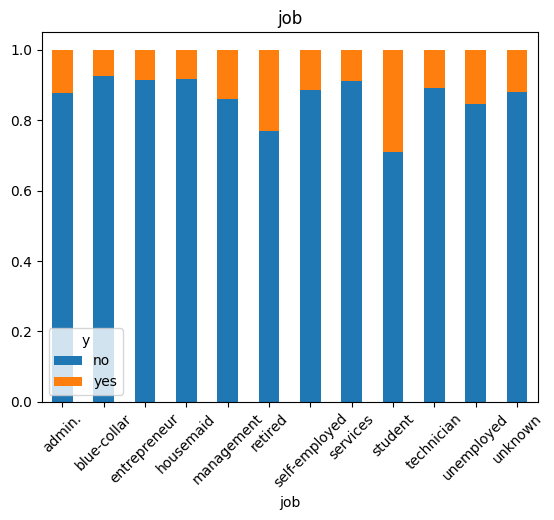

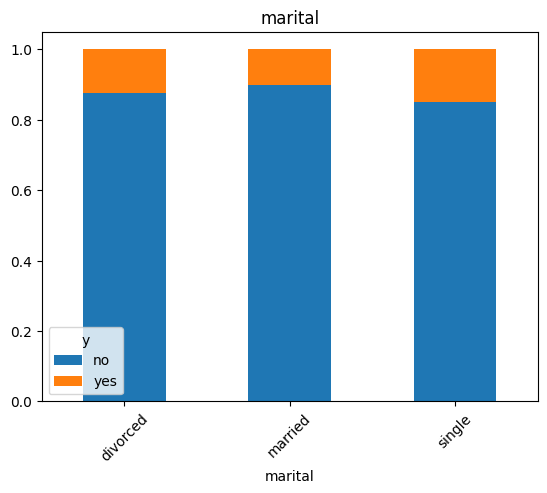

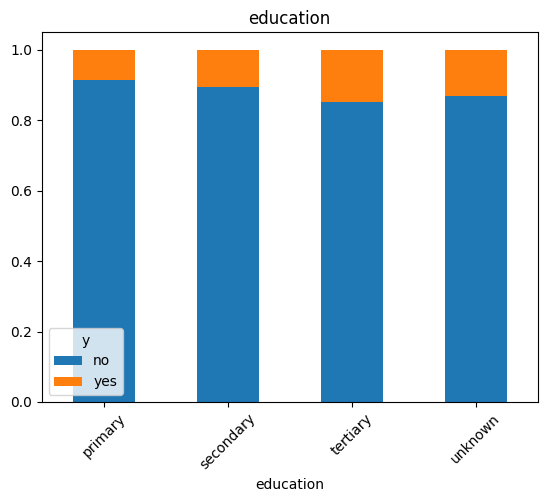

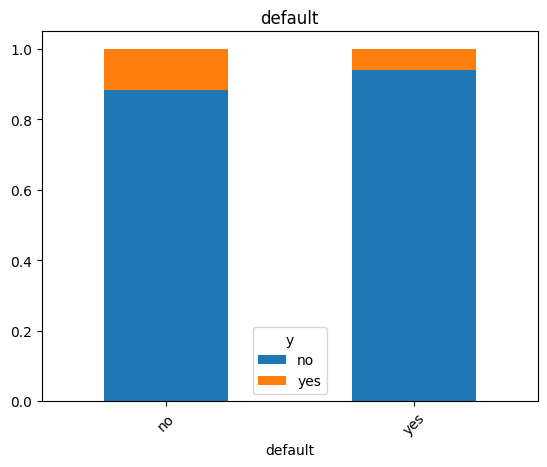

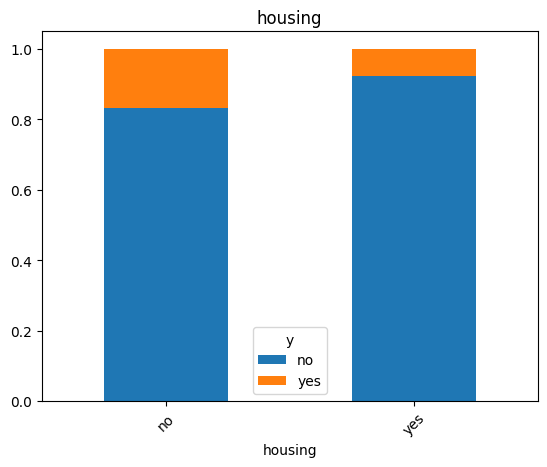

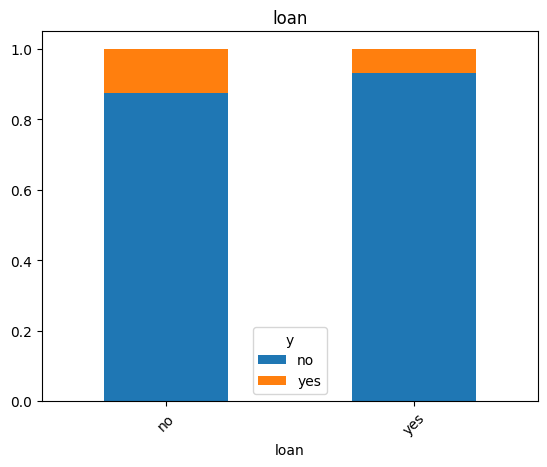

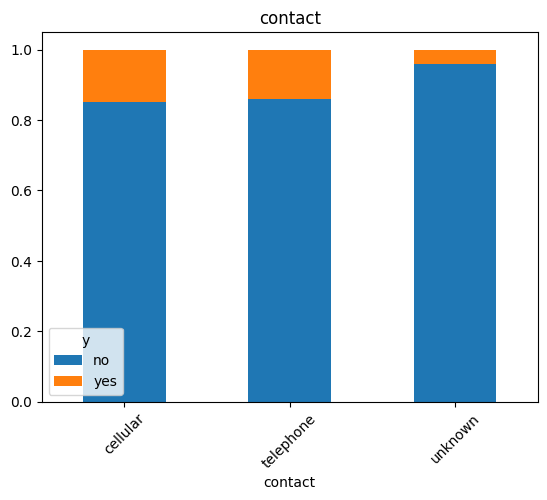

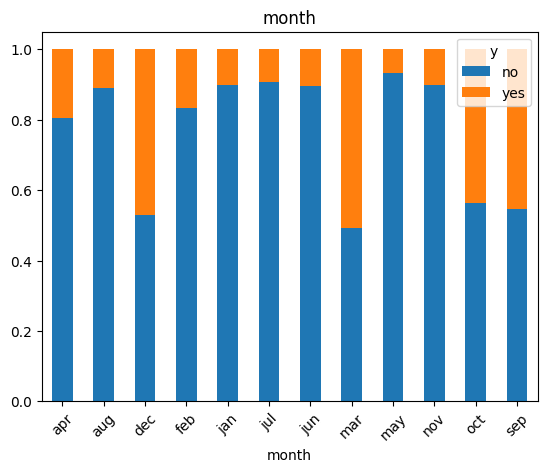

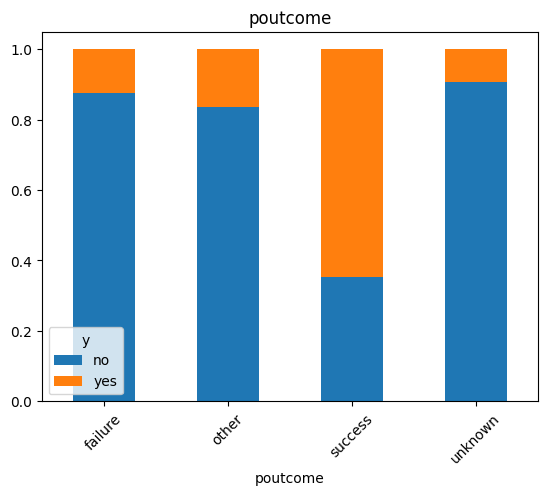

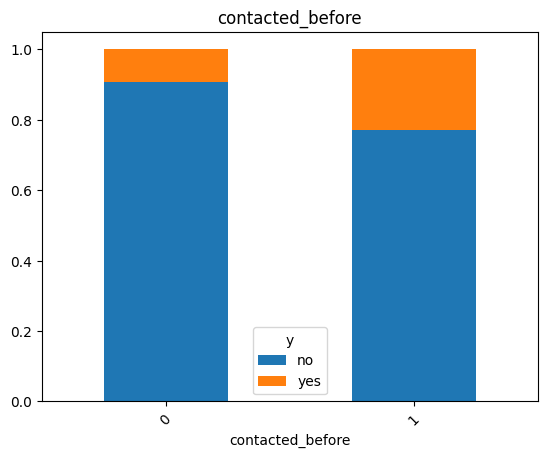

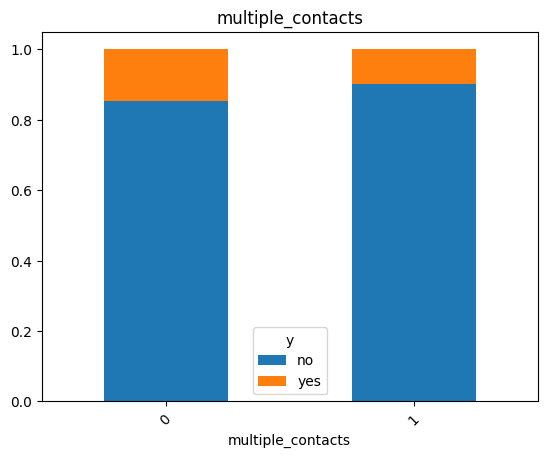

In [25]:
cat_cols = list(X_train.select_dtypes(include="object").columns) + ["contacted_before", "multiple_contacts"]

for col in cat_cols:
    temp = X_train[[col]].copy()
    temp["y"] = y_train.squeeze()
    ratio = temp.groupby(col)["y"].value_counts(normalize=True).unstack()
    ratio.plot(kind="bar", stacked=True)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

Tras la visualización de los gráficos decido quedarme con todas la variable categóricas porque todas muestran algún grado de diferencia en la tasa de "yes" entre categorías.

De las variables númericas elimino:
- "pdays": sutituida por "contacted_before".
- "campaign": sustituida por multiple_contacts.
- "day": sin relación con el target.
- "previous": recoge la misma información que "contacted_before"

### Selección de features

In [26]:
# Primero eliminamos las varibales descartadas
cols_desc = ["pdays", "campaign", "day", "previous"]

X_train = X_train.drop(columns=cols_desc)
X_test = X_test.drop(columns=cols_desc)

In [27]:
# Selección de features
features = [
    # Numéricas
    "age", "balance", "duration",
    # Binarias creadas
    "contacted_before", "multiple_contacts",
    # Categóricas
    "job", "marital", "education", "default", "housing", "loan",
    "contact", "month", "poutcome"
]

### Tratamiento de variables

##### Pasar variables con valores "yes" y "no" a binarias

In [28]:
# Pasar target a binaria
y_train = y_train.squeeze().map({"yes": 1, "no": 0})
y_test = y_test.squeeze().map({"yes": 1, "no": 0})

In [29]:
# Pasar el resto a binarias
cols_binar = ["default", "housing", "loan"]

for col in cols_binar:
    X_train[col] = X_train[col].map({"yes": 1, "no": 0})
    X_test[col] = X_test[col].map({"yes": 1, "no": 0})

##### Aplicar get_dummies al resto de categóricas

In [30]:
X_train = pd.get_dummies(X_train, columns=["job", "marital", "education", "contact", "month", "poutcome"])
X_test = pd.get_dummies(X_test, columns=["job", "marital", "education", "contact", "month", "poutcome"])

##### Calcular asimetría de las variables numéricas y aplicar transformación a las que proceda

In [31]:
num_cols = ["age", "balance", "duration"]

skewness = X_train[num_cols].skew()

for col, skew in skewness.items():
    if abs(skew) > 1:
        print(f"{col}: {skew:.2f} → necesita transformación")
    else:
        print(f"{col}: {skew:.2f} → ok")

age: 0.69 → ok
balance: 8.34 → necesita transformación
duration: 3.21 → necesita transformación


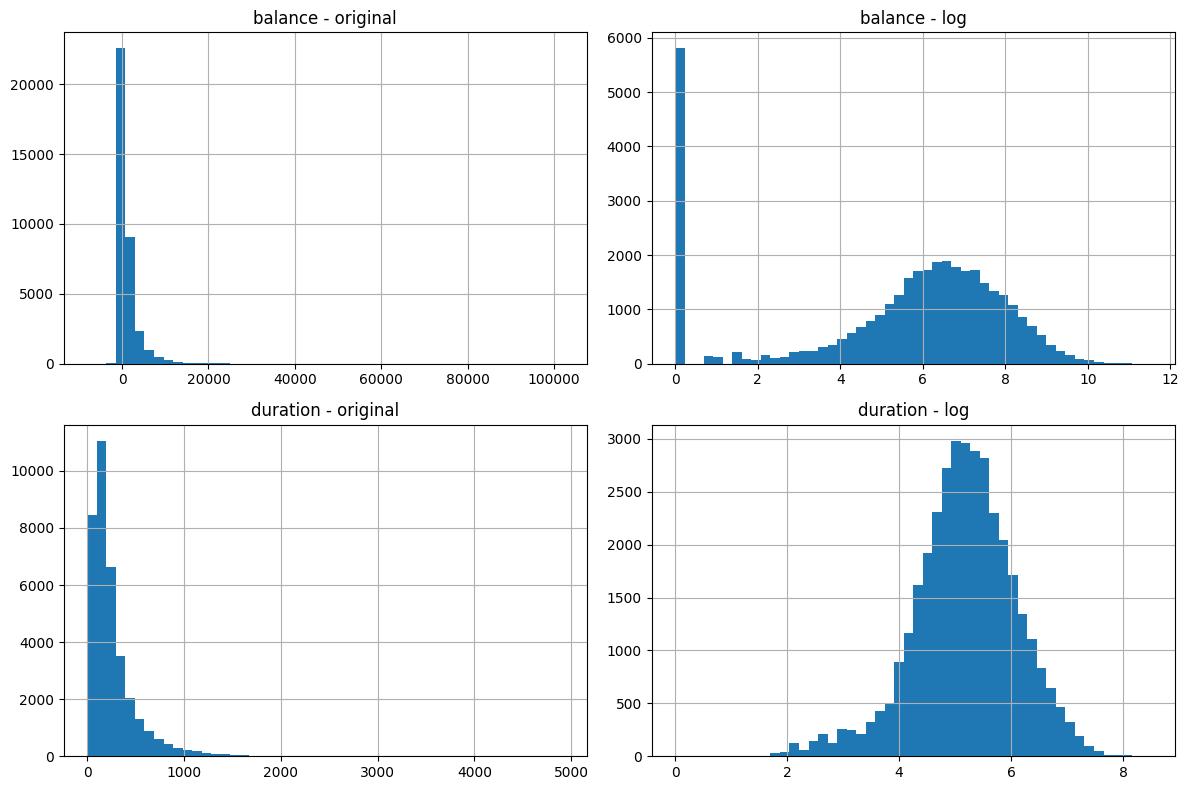

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(["balance", "duration"]):
    # Antes
    X_train[col].hist(ax=axes[i, 0], bins=50)
    axes[i, 0].set_title(f"{col} - original")

    # Transformación
    X_train[f"{col}_log"] = np.log1p(X_train[col].clip(lower=0))

    # Después
    X_train[f"{col}_log"].hist(ax=axes[i, 1], bins=50)
    axes[i, 1].set_title(f"{col} - log")

plt.tight_layout()
plt.show()

In [33]:
# Transformación logarítmica tambien en test
columnas = ["balance", "duration"]

for col in columnas:
    X_test[f"{col}_log"] = np.log1p(X_test[col].clip(lower=0))

### Seleción de modelo

In [34]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


No usaremos como métrica para evaluar el modelo el accuracy porque el target "yes" está muy desbalanceado (88/12).


El classification_report muestra precision, recall y F1 por clase, lo que nos permite ver como se comporta el modelo especificamente

 con la clase minoritaria "yes", que es la que mas nos interesa predecir correctamente.

In [35]:
y_pred_train = tree.predict(X_train)
y_pred_val = tree.predict(X_test)

print("TRAIN")
print(classification_report(y_train, y_pred_train))

print("TEST")
print(classification_report(y_test, y_pred_val))

TRAIN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     31937
           1       1.00      1.00      1.00      4231

    accuracy                           1.00     36168
   macro avg       1.00      1.00      1.00     36168
weighted avg       1.00      1.00      1.00     36168

TEST
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7985
           1       0.46      0.47      0.47      1058

    accuracy                           0.87      9043
   macro avg       0.69      0.70      0.70      9043
weighted avg       0.87      0.87      0.87      9043



Podemos observar que el arbol sin regularizar está claramente sobreajustado, en Train memoriza perfectamente y en Test no generaliza bien.

### Regresión Logística (baseline)

In [40]:
# Primero hay que escalar porque a diferencia del árbol la regresión logística si es sensible a la escala de variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("=== REGRESIÓN LOGÍSTICA ===")
print(classification_report(y_test, y_pred_lr))

=== REGRESIÓN LOGÍSTICA ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.65      0.37      0.47      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.67      0.71      9043
weighted avg       0.89      0.90      0.89      9043



### Comparación: Árbol Base vs Regresión Logística (baseline)

| Métrica clase `yes` | Árbol Base | Regresión Logística |
|---|---|---|
| Precision | 0.46 | 0.65 |
| Recall | 0.47 | 0.37 |
| F1 | 0.47 | 0.47 |
| Accuracy | 0.87 | 0.90 |

#### Conclusiones

- **F1 igual**: ambos modelos obtienen F1=0.47 en la clase `yes`, punto de partida equivalente.

- **Perfiles distintos**: la regresión logística es más precisa (0.65 vs 0.46) 
pero detecta menos clientes potenciales (recall 0.37 vs 0.47). El árbol base 
encuentra más `yes` pero con más errores.

- **Overfitting**: el árbol base memoriza train (F1=1.00) mientras que la 
regresión logística generaliza mejor por naturaleza al ser un modelo más simple.

- **Conclusión**: ninguno de los dos es suficiente. La regresión logística 
es más estable pero pierde demasiados clientes potenciales (recall 0.37).

    Justifica proceder con la optimización del árbol para mejorar ambas métricas.

###  Elección de Hiperparámetros

#### Elección del grid de hiperparámetros

- **`max_depth`** `[3, 5, 7, 10, 15]`: controla la profundidad máxima del árbol. 
El árbol base sin restricciones está claramente sobreajustado, por lo que necesitamos 
limitar su profundidad. Valores bajos evitan el overfitting pero pueden causar underfitting.

- **`min_samples_split`** `[2, 10, 50, 100]`: mínimo de muestras necesarias para dividir 
un nodo. Valores altos impiden que el árbol haga splits sobre grupos muy pequeños, 
reduciendo el overfitting.

- **`min_samples_leaf`** `[1, 5, 10, 20]`: mínimo de muestras que debe tener una hoja. 
Complementa a `min_samples_split`, hojas con pocas muestras suelen ser ruido memorizado.

- **`class_weight`** `[None, "balanced"]`: dado el desbalance 88/12, probamos si compensar 
la clase minoritaria mejora el F1 sobre `yes`. Con `balanced` el árbol penaliza más 
los errores en la clase minoritaria.

In [41]:
param_grid = {
    "max_depth": [3, 5, 7, 10, 15],
    "min_samples_split": [2, 10, 50, 100],
    "min_samples_leaf": [1, 5, 10, 20],
    "class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)
print("Mejor F1 en CV:", grid_search.best_score_.round(4))

Mejores hiperparámetros: {'class_weight': 'balanced', 'max_depth': 15, 'min_samples_leaf': 5, 'min_samples_split': 100}
Mejor F1 en CV: 0.5235


#### Mejores hiperparámetros encontrados

| Hiperparámetro | Valor | Razonamiento |
|---|---|---|
| `class_weight` | `balanced` | Compensar el desbalance 88/12 mejora el F1 en la clase minoritaria |
| `max_depth` | `15` | El árbol necesita bastante profundidad para capturar los patrones, no es un modelo simple |
| `min_samples_leaf` | `5` | Regularización moderada, evita hojas con muy pocas muestras |
| `min_samples_split` | `100` | Regularización alta, evita splits sobre grupos muy pequeños |

**Mejor F1 en CV: 0.52** — mejora respecto al árbol base en test (0.47), aunque 
sigue siendo moderado. 

#### Comparar con el árbol base

In [37]:
tree_optimizado = grid_search.best_estimator_

y_pred_train_opt = tree_optimizado.predict(X_train)
y_pred_test_opt = tree_optimizado.predict(X_test)

print("=== ÁRBOL BASE ===")
print("TEST")
print(classification_report(y_test, y_pred_val))

print("=== ÁRBOL OPTIMIZADO ===")
print("TRAIN")
print(classification_report(y_train, y_pred_train_opt))
print("Test")
print(classification_report(y_test, y_pred_test_opt))

=== ÁRBOL BASE ===
TEST
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7985
           1       0.46      0.47      0.47      1058

    accuracy                           0.87      9043
   macro avg       0.69      0.70      0.70      9043
weighted avg       0.87      0.87      0.87      9043

=== ÁRBOL OPTIMIZADO ===
TRAIN
              precision    recall  f1-score   support

           0       0.99      0.82      0.90     31937
           1       0.41      0.93      0.57      4231

    accuracy                           0.84     36168
   macro avg       0.70      0.88      0.74     36168
weighted avg       0.92      0.84      0.86     36168

Test
              precision    recall  f1-score   support

           0       0.98      0.82      0.89      7985
           1       0.38      0.85      0.53      1058

    accuracy                           0.82      9043
   macro avg       0.68      0.83      0.71      9043
weighted avg  

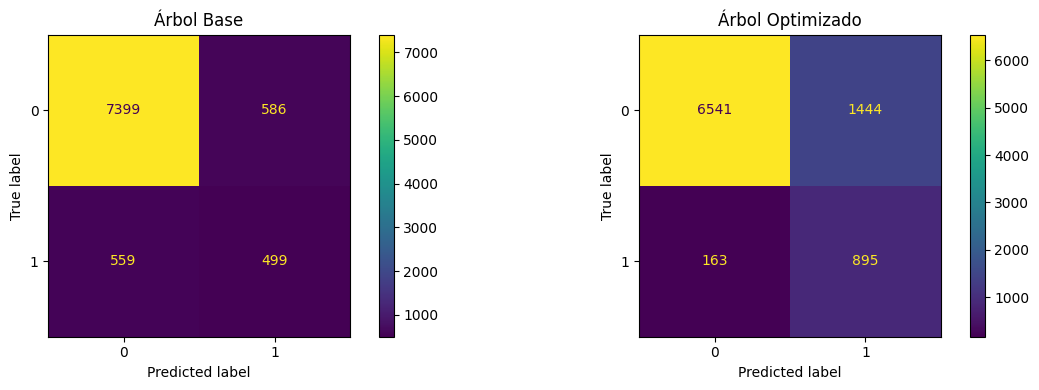

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_val, ax=axes[0])
axes[0].set_title("Árbol Base")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_opt, ax=axes[1])
axes[1].set_title("Árbol Optimizado")

plt.tight_layout()
plt.show()

### Métricas: Árbol Base vs Árbol Optimizado

| Métrica clase `yes` | Árbol Base | Árbol Optimizado Train | Árbol Optimizado Test |
|---|---|---|---|
| Precision | 0.46 | 0.41 | 0.38 |
| Recall | 0.47 | 0.93 | 0.85 |
| F1 | 0.47 | 0.57 | 0.53 |
| Accuracy | 0.87 | 0.84 | 0.82 |

#### Conclusiones

- **Overfitting controlado**: la diferencia entre train y test en el árbol optimizado 
es pequeña (F1: 0.57 vs 0.53), señal de buena generalización. El árbol base 
memorizaba train con F1=1.00.

- **Recall muy mejorado**: pasa de 0.47 a 0.85 en test. El modelo optimizado 
detecta casi el doble de clientes potenciales que el base.

- **Precision más baja**: baja de 0.46 a 0.38, efecto directo del 
`class_weight=balanced`. Se asume este coste porque en marketing directo 
el recall es más valioso que la precision.

- **Accuracy ligeramente inferior**: baja de 0.87 a 0.82, esperado al 
compensar el desbalance. No es una métrica relevante en este problema.

- **F1 mejorado**: sube de 0.47 a 0.53 en test, mejora moderada pero 
consistente con el objetivo de maximizar la detección de la clase minoritaria.

### Matriz de Confusión: Árbol Base vs Árbol Optimizado

|  | Árbol Base | Árbol Optimizado |
|---|---|---|
| Verdaderos Positivos (`yes` correctos) | 499 | 895 |
| Falsos Negativos (`yes` perdidos) | 559 | 163 |
| Falsos Positivos (`no` mal clasificados) | 586 | 1444 |
| Verdaderos Negativos (`no` correctos) | 7399 | 6541 |

#### Conclusiones

- **Detección de clientes potenciales**: el optimizado captura el 85% de los `yes` 
frente al 47% del base, reduce los falsos negativos de 559 a 163.

- **Trade-off asumible**: los falsos positivos suben de 586 a 1444, es decir, 
se contacta a más clientes que no comprarán. En marketing directo el coste 
de una llamada innecesaria es menor que el de perder un cliente potencial.

- **Conclusión**: el árbol optimizado es claramente superior para el objetivo 
del negocio, maximizar la detección de clientes que suscribirán el depósito.